In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", None)

In [2]:
cpu_df = pd.read_csv(
    "../data/Processed/cpu_master.csv"
)

In [3]:
# convert timestamp
cpu_df["timestamp"] = pd.to_datetime(
    cpu_df["timestamp"]
)

In [ ]:
cpu_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype              
---  ------       --------------  -----              
 0   hostId       1500 non-null   int64              
 1   timestamp    1500 non-null   datetime64[ns, UTC]
 2   hostName     1500 non-null   object             
 3   cpuUsagePct  1500 non-null   float64            
 4   status       1500 non-null   object             
dtypes: datetime64[ns, UTC](1), float64(1), int64(1), object(2)
memory usage: 58.7+ KB


In [5]:
# missing values analysis
cpu_df.isnull().sum()

hostId         0
timestamp      0
hostName       0
cpuUsagePct    0
status         0
dtype: int64

In [6]:
# duplicate check
cpu_df.duplicated().sum()

np.int64(0)

In [7]:
# Status distribution
cpu_df["status"].value_counts()

status
Normal     1000
Warning     500
Name: count, dtype: int64

In [9]:
cpu_df["status_encoded"] = (
    cpu_df["status"]
    .map({
        "Normal":0,
        "Warning":1
    })
)

cpu_df.head()

,hostId,timestamp,hostName,cpuUsagePct,status,status_encoded
0,2,2026-06-08 12:46:13.776000+00:00,10.10.10.150,1.97,Normal,0
1,2,2026-06-08 12:51:15.113000+00:00,10.10.10.150,1.81,Normal,0
2,2,2026-06-08 12:56:12.448000+00:00,10.10.10.150,3.39,Normal,0
3,2,2026-06-08 13:01:12.997000+00:00,10.10.10.150,1.92,Normal,0
4,2,2026-06-08 13:06:13.341000+00:00,10.10.10.150,5.37,Normal,0


In [11]:
# timestamp storing
cpu_df = cpu_df.sort_values(
    ["hostName","timestamp"]
)
# reset index
cpu_df = cpu_df.reset_index(drop=True)

In [12]:
# Check CPU range
cpu_df["cpuUsagePct"].describe()

count    1500.000000
mean       11.830433
std        12.160043
min         1.280000
25%         2.020000
50%         4.205000
75%        27.520000
max        33.140000
Name: cpuUsagePct, dtype: float64

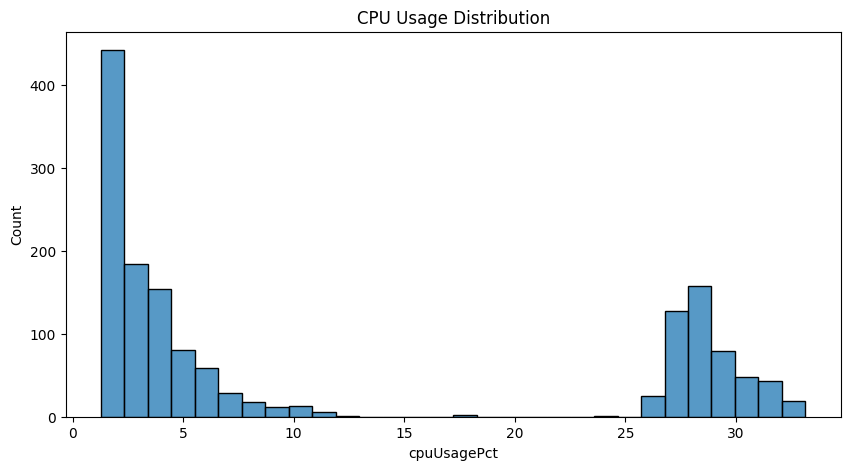

In [13]:
# CPU distribution plot
plt.figure(figsize=(10,5))

sns.histplot(
    cpu_df["cpuUsagePct"],
    bins=30
)

plt.title("CPU Usage Distribution")
plt.show()

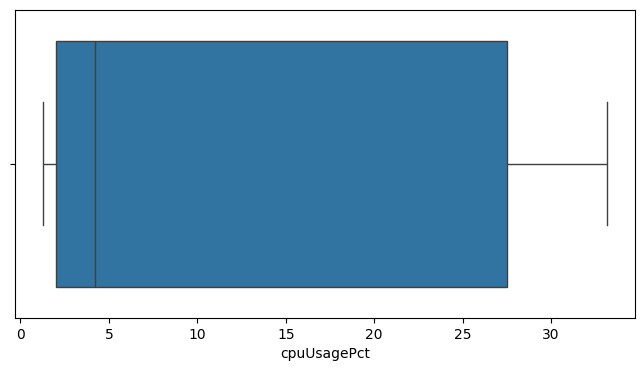

In [14]:
# Boxplot
plt.figure(figsize=(8,4))

sns.boxplot(
    x=cpu_df["cpuUsagePct"]
)

plt.show()

In [15]:
# Outlier detection
Q1 = cpu_df["cpuUsagePct"].quantile(0.25)

Q3 = cpu_df["cpuUsagePct"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR

upper = Q3 + 1.5*IQR

print(lower)
print(upper)

-36.23
65.77


In [16]:
# Count outliers
outliers = cpu_df[
    (cpu_df["cpuUsagePct"] < lower)
    |
    (cpu_df["cpuUsagePct"] > upper)
]

print(len(outliers))

0


In [17]:
# Check sampling interval
genai = cpu_df[
    cpu_df["hostName"] ==
    cpu_df["hostName"].unique()[0]
]

# calculate interval
genai["timestamp"].diff().value_counts()

timestamp
0 days 00:05:00.344000    3
0 days 00:05:00.873000    2
0 days 00:04:58.504000    2
0 days 00:04:59.931000    2
0 days 00:05:00.029000    2
                         ..
0 days 00:05:00.071000    1
0 days 00:05:02.187000    1
0 days 00:05:02.836000    1
0 days 00:04:59.192000    1
0 days 00:05:00.277000    1
Name: count, Length: 477, dtype: int64

In [18]:
genai["timestamp"].diff().describe()

count                          499
mean     0 days 00:04:59.861573146
std      0 days 00:00:04.356914616
min         0 days 00:04:10.926000
25%         0 days 00:04:58.526000
50%         0 days 00:05:00.068000
75%         0 days 00:05:01.289000
max         0 days 00:05:35.339000
Name: timestamp, dtype: object

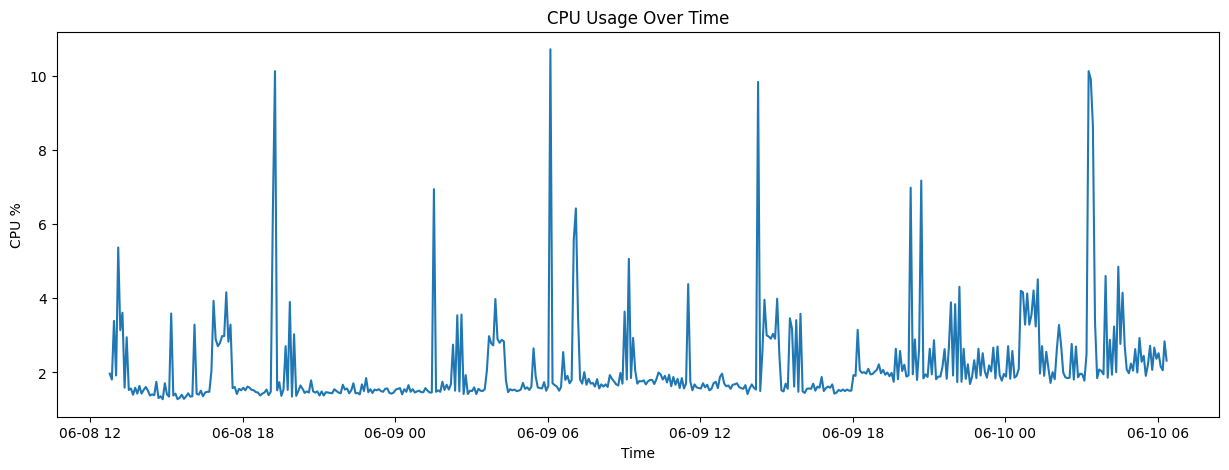

In [19]:
# Visualize CPU trends
plt.figure(figsize=(15,5))

plt.plot(
    genai["timestamp"],
    genai["cpuUsagePct"]
)

plt.title("CPU Usage Over Time")
plt.xlabel("Time")
plt.ylabel("CPU %")

plt.show()

In [20]:
# server wise count
cpu_df.groupby(
    "hostName"
)["cpuUsagePct"].count()

hostName
10.10.10.150    500
10.10.10.2      500
10.10.10.65     500
Name: cpuUsagePct, dtype: int64

In [21]:
cpu_cleaned = cpu_df[
    [
        "hostId",
        "hostName",
        "timestamp",
        "cpuUsagePct",
        "status",
        "status_encoded"
    ]
]

In [22]:
cpu_cleaned.to_csv(
    "../data/Processed/cpu_cleaned.csv",
    index=False
)

In [23]:
# average cpu usage per server
avg_cpu = (
    cpu_df.groupby(["hostId", "hostName"])["cpuUsagePct"]
    .mean()
    .reset_index()
)

avg_cpu["cpuUsagePct"] = avg_cpu["cpuUsagePct"].round(2)

print("Average CPU Usage Per Server")
print("-" * 50)

for _, row in avg_cpu.iterrows():
    print(
        f"Host ID   : {row['hostId']}\n"
        f"Host Name : {row['hostName']}\n"
        f"Average CPU Usage : {row['cpuUsagePct']}%\n"
    )

Average CPU Usage Per Server
--------------------------------------------------
Host ID   : 1
Host Name : 10.10.10.65
Average CPU Usage : 4.56%

Host ID   : 2
Host Name : 10.10.10.150
Average CPU Usage : 2.14%

Host ID   : 3
Host Name : 10.10.10.2
Average CPU Usage : 28.79%

